# Creating A Cohort and Pulling Relevant Data Using The Longitudinal Data Table in HTAN

```
Title:   Identifiying and Compiling Cases and Samples with Longitudinal Data in HTAN
Author:  Jennifer Altreuter (jennifer@ds.dfci.harvard.edu), Dar'ya Pozhidayeva (dpozhida@systemsbiology.org), Kristen Anton (Kristen.anton@whiterivercomputing.com)
Created: February 6th, 2026
```

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/isb-cgc/Community-Notebooks/blob/master/HTAN/Python%20Notebooks/Creating_A_Cohort_and_Pulling_Relevant_Data_Using_The_Longitudinal_Data_in_HTAN.ipynb)

# 1. Introduction & Overview
[HTAN](https://humantumoratlas.org/) is a National Cancer Institute (NCI)-funded Cancer Moonshot initiative to construct 3-dimensional atlases of the dynamic cellular, morphological, and molecular features of human cancers as they evolve from precancerous lesions to advanced disease ( [Cell April 2020](https://www.sciencedirect.com/science/article/pii/S0092867420303469)).

HTAN contains a diverse set of metadata. Sometimes these data have a longitudinal component, but it can be difficult to identify and organize the time-based relationships across participants and events. This notebook will showcase how this can be accomplished.


### Longitudinal Data in HTAN Phase 1

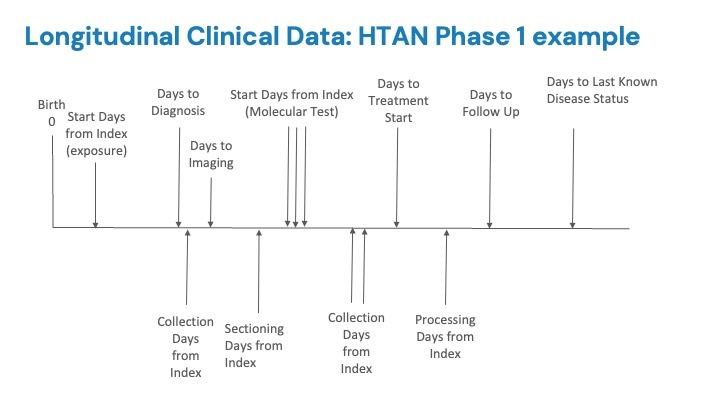


### Longitudinal Clinical Data Timeline — HTAN Phase 1 (Example)

This diagram represents a **longitudinal timeline for a single participant** in **HTAN Phase 1**, where all events are aligned using **“days from index”** (commonly birth or another defined reference date).

It shows how **clinical events** and **research/sample events** occur over time relative to the same starting point.

#### Timeline Anchor
- **Birth (Day 0)** serves as the reference point.
- All other events are measured as days before or after this index date.

#### Clinical Milestones
These describe the participant’s disease course and care:

- **Days to diagnosis** — When the disease was first identified.
- **Days to treatment start** — When therapy began.
- **Days to follow-up** — Subsequent clinical visits or monitoring points.
- **Days to last known disease status** — Most recent clinical assessment of disease state.

#### Research and Biospecimen Events
These capture when biological samples and analyses occur:

- **Collection days from index** — When biospecimens were collected.
- **Processing days from index** — When samples were processed in the lab.
- **Sectioning days from index** — When tissue samples were sectioned.
- **Start days from index (molecular test)** — When molecular assays (e.g., sequencing) began.
- **Days to imaging** — When imaging studies were performed.

### Longitudinal Data Table – Overview

The BigQuery table we will be using, provides a summary of HTAN participants who have clinical data collected at multiple timepoints. Instead of showing individual files or assays, each row represents a single participant and indicates whether they have follow-up visits, additional biospecimen collections, or multiple data-generating events over time (for example, repeated sampling or different types of assays).

The table is useful for quickly identifying which participants have longitudinal data available in Phase 1 of HTAN, without needing to search through detailed file-level tables.

For more detailed instructions about how the longitudinal table is constructed, please check section #8 in this notebook for supplementary information.


For more questions about HTAN data in general, please check refer to the [HTAN Manual](https://docs.humantumoratlas.org/).





**Table Column Descriptions**

For reference, the columns in the table can be explained as follows:

**HTAN_Participant_ID**

- Unique HTAN identifier for the participant. Links all recorded events back to the same individual.

**Start**

- Number of days from the participant’s date of birth (index date) to the start of an event (such as diagnosis, treatment, exposure, or follow-up milestone).

**End**

- Number of days from the participant’s date of birth (index date) to the end of the same event.

**Event_Type**

- High-level category of the event occurring between the Start and End timepoints (e.g., Diagnosis, Therapy, Follow-Up, Vital Status).

**Detail**

- More specific description of the event type, providing finer context (for example, specific diagnosis, therapy type, or status description).

**Suspicious_Records**

- Flag or note indicating that the event timing or pattern may be inconsistent, unusual, or logically questionable and may require review.

### 1.1 Goal

As mentioned above, here we'll demonstrate how HTAN Phase 1 longitudinal clinical data can be filtered and used as an index to connect participant-level clinical timelines with biospecimen, therapy, and assay data.

Specifically, this notebook:

- Introduces the HTAN longitudinal BigQuery table; and
- Demonstrates how to use the longitudinal BiqQuery table to:
  - Apply cohort-level filters (e.g., diagnosis, therapy, biopsy)  
  - Construct participant-level event paths that describe disease trajectories; and
  - Use biospecimen identifiers embedded in clinical events to retrieve associated data files from the SageBionetworks Synapse storage warehouse.


### 1.2 Inputs, Outputs, & Data

**Inputs**

- **HTAN longitudinal clinical data**, which contain participant-level events (e.g., diagnosis, therapy, follow-up, vital status) with associated timepoints.
- **Google BigQuery metadata tables** that contain file- and assay-level metadata.

**Outputs**

- A **filtered longitudinal cohort** of participants meeting defined clinical criteria  
- A **time-ordered event table** describing each participant’s disease course  
- A **participant-level event path** summarizing clinical trajectories  
- A **list of biospecimen identifiers** extracted from clinical records  
- Linked **molecular and assay data** retrieved from BigQuery tables using those biospecimen IDs  


### 1.3 Notes
The queries and results in this notebook correspond to ISB-CGC HTAN Release 7.0.

To choose a different release, edit the BigQuery table names in this notebook by replacing the relevant string endings:
- `r7` with a selected numbered release, e.g., `r2`
- `gc` with `cds` (if applicable)

To get results for the most current data release, replace:
- `r7` with `current`
- `HTAN_versioned` with `HTAN`


### ⚠️PAUSE
Notebooks associated with ISB-CGC HTAN Releases 7.0 or earlier are based on the **HTAN Phase 1 Data Model**. Please be aware that the structure, terminology, and available data elements may differ from those in Phase 2.

# 2. Relevant Libraries for Analysis

To get started, we'll need to call the pandas python library and some additional libraries for plotting later.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 3. Google Authentication

Running the BigQuery cells in this notebook requires a Google Cloud Project, instructions for creating a project can be found in the [Google Documentation](https://cloud.google.com/resource-manager/docs/creating-managing-projects#console). The instance needs to be authorized to bill the project for queries. For more information on getting started in the cloud see [Quick Start Guide to ISB-CGC](https://nbviewer.org/github/isb-cgc/Community-Notebooks/blob/master/Notebooks/Quick_Start_Guide_to_ISB_CGC.ipynb) and alternative authentication methods can be found in the [Google Documentation](https://cloud.google.com/resource-manager/docs/creating-managing-projects#console).

## 3.1 Authenticating with Google Credentials

#### Option 1. Running in Google Colab

Before getting started, keep in mind that there are some differences in running this notebook depending on if you are using Google Colab or running locally. We've included notes such as the following to skip or run specific lines of code depending on your setup.

If you are using Google Colab, run the code block below to authenticate:

In [2]:
from google.colab import auth
auth.authenticate_user()

#### Option 2. Running on local machine

Alternatively, if you're running the notebook locally, take the following steps to authenticate.

1.   Run `gcloud auth application-default login` on your local machine
2.   Run the command below replacing `<path to key>` with the path to your credentials file

In [3]:
#%env GOOGLE_APPLICATION_CREDENTIALS=<path to key>

## 3.2 Initializing the Google BigQuery client

In [2]:
# Import the Google BigQuery client
from google.cloud import bigquery

# Set the google project that will be billed for this notebook's computations
google_project = '<my-project>'

# Create a client to access the data within BigQuery
client = bigquery.Client(google_project)

#4. Pull Data from Google BigQuery

We'll start by pulling the longitudinal data table using BigQuery.

In [4]:
all_longitudinal_data = client.query("""
SELECT * FROM `isb-cgc-bq.HTAN_versioned.phase1_longitudinal_data_r7`
""").result().to_dataframe()

In [5]:
all_longitudinal_data.head(5)

,HTAN_Participant_ID,Start,End,Event_Type,Detail,Suspicious_Records
0,HTA3_10033,27356,27356,Vital Status,Dead,None
1,HTA3_11006,24894,24894,Vital Status,Dead,None
2,HTA3_11013,27190,27190,Vital Status,Dead,None
3,HTA3_11016,25443,25443,Vital Status,Dead,None
4,HTA3_11024,19979,19979,Vital Status,Dead,None


# 5. Build a Cohort using the Longitudinal Table
Next, we'll build a practical cohort of participants who have enough clinical and molecular information to be interesting to study. Specifically, we’re looking for **people who have a recorded diagnosis of intestinal adenocarcinmoa, at least one therapy, and at least one biospecimen sample available in the longitudinal table.**

By bringing these pieces together, we can start to explore how what happened clinically — like treatments and disease progression. We can then connect this information to spatial gene expression data.


In [6]:
#Make a copy of the table
lng_table_cohort = all_longitudinal_data.copy()

#Ensure time column numeric
lng_table_cohort["Start"] = pd.to_numeric(lng_table_cohort["Start"], errors="coerce")

In [7]:
#Must have the "adenocarcinoma intestinal" diagnosis
adeno_ids = lng_table_cohort[
    (lng_table_cohort["Event_Type"] == "Diagnosis") &
    (lng_table_cohort["Detail"].str.contains("adenocarcinoma intestinal", case=False, na=False))
]["HTAN_Participant_ID"].unique()
#Count
len(adeno_ids)

10

In [8]:
#Must have at least one Therapy
therapy_ids = lng_table_cohort[lng_table_cohort["Event_Type"] == "Therapy"]["HTAN_Participant_ID"].unique()
#Count
len(therapy_ids)

265

We’re also adding a requirement that participants have at least one biopsy event, which we identify by the presence of an HTAN biospecimen ID in the longitudinal table.

The reason for this is: to connect clinical information to assay data, we need a physical sample that could have been processed and profiled. If a participant doesn’t have a recorded biopsy (or resection) sample, there’s nothing to link their clinical timeline to molecular data. Requiring at least one biospecimen ID helps ensure that the cohort we define can actually support the type of integrated clinical and spatial transcriptomics analysis.


In [9]:
biopsy_ids = lng_table_cohort[
    lng_table_cohort["Detail"].str.contains(r"HTA\d+_\d+_\d+", na=False, regex=True)
]["HTAN_Participant_ID"].unique()
#Count
len(biopsy_ids)

1727

Next, we'll use our criteria above to gather an intersection we'll use to filter the whole dataset.

In [10]:
qualified_ids = (
    set(adeno_ids)
    .intersection(biopsy_ids)
    .intersection(therapy_ids))

cohort = lng_table_cohort[lng_table_cohort["HTAN_Participant_ID"].isin(qualified_ids)].copy()
cohort.head(5)

,HTAN_Participant_ID,Start,End,Event_Type,Detail,Suspicious_Records
46,HTA12_258,18927,18927,Vital Status,Alive,None
47,HTA12_259,17868,17868,Vital Status,Alive,None
50,HTA12_270,14517,14517,Vital Status,Alive,None
52,HTA12_272,19780,19780,Vital Status,Alive,None
1259,HTA12_257,21279,21279,Diagnosis,Adenocarcinoma intestinal type,None


Looks like in total there are 7 participants in our filtered cohort compared to the total 1813 in the full table.

In [11]:
len(all_longitudinal_data["HTAN_Participant_ID"].unique())

1813

In [12]:
len(cohort["HTAN_Participant_ID"].unique())

7

# 6. Plot The Cohort Table

By itself this table will be useful, but we'd like to plot this information as well to make it more digestible visually.


The plot we'll be constructing will show clinical event timelines for multiple HTAN participants, with each row representing one person and dots marking events in the order they occurred.

The x-axis will be the sequence of events over time, and the colors should indicate different event types such as diagnosis, biopsy/resection procedures, chemotherapy, recurrence, follow-up, and vital status.

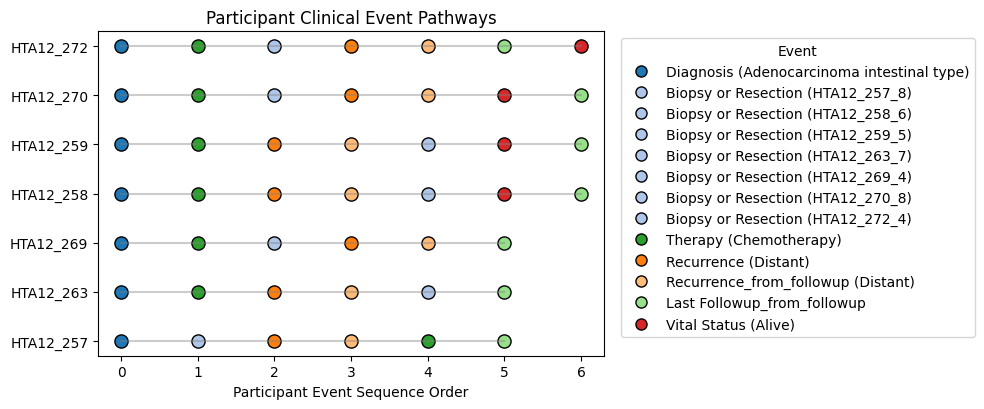

In [13]:
# Sort chronologically
cohort = cohort.sort_values(["HTAN_Participant_ID", "Start"])

# Step order
cohort["Step_Number"] = cohort.groupby("HTAN_Participant_ID").cumcount()

# Full event label
cohort["Event_Label"] = cohort["Event_Type"]
cohort.loc[cohort["Detail"].notna(), "Event_Label"] = (
    cohort["Event_Type"] + " (" + cohort["Detail"].astype(str) + ")"
)

#Control color grouping
def color_group(row):
    if "biopsy" in row["Event_Type"].lower() or "resection" in row["Event_Type"].lower():
        return "Biopsy/Resection"
    return row["Event_Label"]  # others stay unique

cohort["Color_Group"] = cohort.apply(color_group, axis=1)

# Participant order
event_counts = cohort.groupby("HTAN_Participant_ID").size()
participants = event_counts.sort_values().index.tolist()
y_positions = {p: i for i, p in enumerate(participants)}

# Color map
unique_groups = cohort["Color_Group"].unique()
palette = sns.color_palette("tab20", len(unique_groups))
group_colors = dict(zip(unique_groups, palette))

plt.figure(figsize=(10, 0.6 * len(participants)))

# Plot
for _, row in cohort.iterrows():
    plt.scatter(
        row["Step_Number"],
        y_positions[row["HTAN_Participant_ID"]],
        color=group_colors[row["Color_Group"]],
        s=90,
        edgecolor="black"
    )

# Connect paths
for pid, group in cohort.groupby("HTAN_Participant_ID"):
    plt.plot(group["Step_Number"],
             [y_positions[pid]] * len(group),
             color="gray", alpha=0.4)

#Organize legend manually
logical_order_keywords = [
    "Diagnosis",
    "Biopsy",
    "Resection",
    "Therapy",
    "Recurrence",
    "Progression",
    "Followup",
    "Vital Status"
]

def logical_sort(label):
    for i, key in enumerate(logical_order_keywords):
        if key.lower() in label.lower():
            return i
    return len(logical_order_keywords)

sorted_labels = sorted(cohort["Event_Label"].unique(), key=logical_sort)

handles = []
for label in sorted_labels:
    # Use grouped color but keep full label text
    if "biopsy" in label.lower() or "resection" in label.lower():
        color = group_colors["Biopsy/Resection"]
    else:
        color = group_colors[label]

    handles.append(
        plt.Line2D([0],[0], marker='o', color='w',
                   markerfacecolor=color,
                   markeredgecolor='black',
                   markersize=8,
                   label=label)
    )

# Formatting
plt.yticks(list(y_positions.values()), list(y_positions.keys()))
plt.xlabel("Participant Event Sequence Order")
plt.title("Participant Clinical Event Pathways")

plt.legend(handles=handles,
           bbox_to_anchor=(1.02,1),
           loc="upper left",
           title="Event")

plt.tight_layout()
plt.show()


Nice, now we can neatly and clearly see the cohort and their trajectory listed in the longitudinal table.

Most participants start with a diagnosis, followed by therapy, a biopsy or resection events, then later recurrence or follow-up milestones. Overall, the figure highlights how clinical trajectories vary between individuals while still following a broadly similar progression pattern.

# 7. Search the ID Provenance Table for Files Tied to Samples

To connect clinical events with molecular data, we first extract biospecimen (biopsy) identifiers directly from the longitudinal table, where these IDs appear in the event details for biopsy or resection events. These biospecimen IDs serve as linkage keys between the clinical timeline and downstream assay data.

We then use the HTAN ID provenance table to map each biospecimen ID to its associated derived samples and file-level identifiers. This provenance mapping allows us to trace each clinical sample forward through processing steps and identify the relevant molecular data files generated from those specimens.


In [14]:
#Double check the participant listing
cohort['HTAN_Participant_ID'].dropna().unique()

array(['HTA12_257', 'HTA12_258', 'HTA12_259', 'HTA12_263', 'HTA12_269',
       'HTA12_270', 'HTA12_272'], dtype=object)

In [15]:
#Extract the HTAN IDs for assayed samples
pattern = r"HTA\d+_\d+(?:_\d+)?"   # HTA + numbers + _ + numbers
ids = cohort[cohort["Detail"].str.contains(pattern, na=False, regex=True)]
#Format for the SQL query we will implement below
ids = ids["Detail"].dropna().unique().tolist()
ids_sql = ", ".join(f"'{i}'" for i in ids)
ids_sql

"'HTA12_257_8', 'HTA12_258_6', 'HTA12_259_5', 'HTA12_263_7', 'HTA12_269_4', 'HTA12_270_8', 'HTA12_272_4'"

In [16]:
#Query the sample in our ID provenance table.
query = f"""
SELECT *
FROM `isb-cgc-bq.HTAN_versioned.id_provenance_r7`
WHERE HTAN_Assayed_Biospecimen_ID IN ({ids_sql})
"""
#Run the query as a dataframe
id_provenance = client.query(query).result().to_dataframe()

In [17]:
#Check the dataframe
id_provenance.head(5)

,HTAN_Data_File_ID,Filename,entityId,Component,Data_Release,GC_Release,HTAN_Center,HTAN_Assayed_Biospecimen_ID,HTAN_Parent_Data_File_ID,HTAN_Originating_Biospecimen_ID,HTAN_Participant_ID,Biospecimen_Path
0,HTA12_257_1008,V10X_auxiliary-spatial_clone/Colorectal_112C1-...,syn61465378,10xVisiumSpatialTranscriptomics-AuxiliaryFiles,Release 6.0,None,HTAN WUSTL,HTA12_257_8,Not Applicable,HTA12_257_8,HTA12_257,HTA12_257_8
1,HTA12_257_1005,V10X_level_1-spatial_clone/GTGGATCAAA-GCCAACCC...,syn61464385,10xVisiumSpatialTranscriptomics-RNA-seqLevel1,Release 6.0,v24.8.1.seq,HTAN WUSTL,HTA12_257_8,None,HTA12_257_8,HTA12_257,HTA12_257_8
2,HTA12_257_1006,V10X_level_1-spatial_clone/GTGGATCAAA-GCCAACCC...,syn61464689,10xVisiumSpatialTranscriptomics-RNA-seqLevel1,Release 6.0,v24.8.1.seq,HTAN WUSTL,HTA12_257_8,None,HTA12_257_8,HTA12_257,HTA12_257_8
3,HTA12_257_2003,V10X_level_2-spatial_clone/HT112C1-U2_ST_Bn1-p...,syn61465586,10xVisiumSpatialTranscriptomics-RNA-seqLevel2,Release 6.0,v24.8.1.seq,HTAN WUSTL,HTA12_257_8,HTA12_257_1005,HTA12_257_8,HTA12_257,HTA12_257_8
4,HTA12_257_2003,V10X_level_2-spatial_clone/HT112C1-U2_ST_Bn1-p...,syn61465586,10xVisiumSpatialTranscriptomics-RNA-seqLevel2,Release 6.0,v24.8.1.seq,HTAN WUSTL,HTA12_257_8,HTA12_257_1006,HTA12_257_8,HTA12_257,HTA12_257_8


We have successfully extracted the biospecimen identifiers referenced in the longitudinal clinical table and used them to identify the subset of samples with associated molecular data. For a follow-up analysis, it could be interesting to focus specifically on the **10xVisiumSpatialTranscriptomics–RNA-seq Level 3** component, which provides processed spatial transcriptomics outputs linked to these biopsied samples.

Importantly, this data type is not under controlled access, meaning the files can be retrieved directly from Synapse without dbGaP authorization. We will use the Synapse command-line interface (CLI) from Sage Bionetworks to programmatically access and download the relevant files associated with these biospecimens.

Synapse CLI documentation:  
https://python-docs.synapse.org/build/html/CommandLineClient.html  

Synapse getting started guide:  
https://help.synapse.org/docs/Getting-Started.1985233890.html


In [18]:
#Subset the provenance table for just Visium Level 3 files
visium_level3 = id_provenance[id_provenance["Component"] == '10xVisiumSpatialTranscriptomics-RNA-seqLevel3']

In [19]:
#Check our file listing
visium_level3.head(5)

,HTAN_Data_File_ID,Filename,entityId,Component,Data_Release,GC_Release,HTAN_Center,HTAN_Assayed_Biospecimen_ID,HTAN_Parent_Data_File_ID,HTAN_Originating_Biospecimen_ID,HTAN_Participant_ID,Biospecimen_Path
5,HTA12_257_3010,V10X_level_3-spatial_clone/HT112C1-U2_ST_Bn1-b...,syn61462233,10xVisiumSpatialTranscriptomics-RNA-seqLevel3,Release 6.0,None,HTAN WUSTL,HTA12_257_8,HTA12_257_1008,HTA12_257_8,HTA12_257,HTA12_257_8
6,HTA12_257_3010,V10X_level_3-spatial_clone/HT112C1-U2_ST_Bn1-b...,syn61462233,10xVisiumSpatialTranscriptomics-RNA-seqLevel3,Release 6.0,None,HTAN WUSTL,HTA12_257_8,HTA12_257_2003,HTA12_257_8,HTA12_257,HTA12_257_8
7,HTA12_257_3011,V10X_level_3-spatial_clone/HT112C1-U2_ST_Bn1-f...,syn61462149,10xVisiumSpatialTranscriptomics-RNA-seqLevel3,Release 6.0,None,HTAN WUSTL,HTA12_257_8,HTA12_257_2003,HTA12_257_8,HTA12_257,HTA12_257_8
8,HTA12_257_3011,V10X_level_3-spatial_clone/HT112C1-U2_ST_Bn1-f...,syn61462149,10xVisiumSpatialTranscriptomics-RNA-seqLevel3,Release 6.0,None,HTAN WUSTL,HTA12_257_8,HTA12_257_1008,HTA12_257_8,HTA12_257,HTA12_257_8
9,HTA12_257_3012,V10X_level_3-spatial_clone/HT112C1-U2_ST_Bn1-m...,syn61462480,10xVisiumSpatialTranscriptomics-RNA-seqLevel3,Release 6.0,None,HTAN WUSTL,HTA12_257_8,HTA12_257_1008,HTA12_257_8,HTA12_257,HTA12_257_8


In [20]:
#Here are the entityIds used by the synapse CLI to obtain the files.
visium_level3["entityId"].unique()

array(['syn61462233', 'syn61462149', 'syn61462480', 'syn61462263',
       'syn61462100', 'syn61462182', 'syn61462171', 'syn61462396',
       'syn61462492', 'syn61462229', 'syn61462343', 'syn61462136',
       'syn61462300', 'syn61462346', 'syn61462477', 'syn61462138',
       'syn61462231', 'syn61462146', 'syn61462152', 'syn61462425',
       'syn61462476', 'syn61462016', 'syn61462420', 'syn61462391'],
      dtype=object)

With our cohort linked to **10x Genomics Visium Level 3** data, we could start asking a number of biological questions:

- Do treated vs untreated patients show different immune gene expression patterns?
- Are certain tumor regions more biologically active?
- Does time since diagnosis affect spatial organization?

and many more...

Try subsetting your own clinical information to answer your hypothesis with HTAN data.

# 8. Relevant Citations and Links

[Sharing Data from the Human Tumor Atlas Network through Standards, Infrastructure, and Community Engagement](https://pubmed.ncbi.nlm.nih.gov/40164800)

# 9. Supplementary Section

For a detailed description of the table used in this notebook, please refer to the following construction guide.

The repo and source code for this table can be found [here](https://github.com/ncihtan/phase1_longitudinal_data).

## HTAN Phase 1 Longitudinal Table — How It’s Built

The HTAN Phase 1 longitudinal table is essentially a **timeline for each participant**. It brings together clinical events, treatments, biospecimens, and molecular tests into one time-ordered view so you can see how each person’s disease progressed over time.

### Step 1: Decide Who Is Included

We start with the **demographics dataset** and define which participants are eligible for longitudinal analysis.

Participants are removed if:

- Their HTAN Center name starts with **“TNP”**, or  
- Their **Days_to_Birth** value is anything other than 0 (with “unknown” treated as 0).

The remaining participants are called the **“ok cases.”** These IDs form the foundation of the longitudinal table.

### Step 2: Pull in All Relevant Data

Next, we load all major HTAN data domains:

- Demographics  
- Diagnosis  
- Follow-Up  
- Molecular Tests  
- Biospecimens  
- Therapy  

Derived biospecimen records are removed so that only **primary biospecimens** are included. Each dataset is then filtered to keep only records linked to the “ok cases.”

### Step 3: Convert Everything Into Timeline Records

All filtered data is reshaped into a unified event table where each row represents a meaningful event:

- **HTAN_Participant_ID**  
- **Start** (event time in days)  
- **End** (if the event spans time)  
- **Event_Type**  
- **Detail** (specific clinical or experimental attribute)

Only rows with a valid detail field are kept so each row corresponds to a real observation or event.

### Step 4: Basic Time Cleaning

To improve data quality:

- Records with **Start = NA** or **Start = 0** are removed  
- Records with **Start = 6573** (a known placeholder value) are removed  

This ensures that events have meaningful, interpretable timepoints.

### Step 5: Build the Core Clinical Timeline

Key clinical events that describe the disease course are prioritized:

**From Demographics**
- Vital Status  

**From Diagnosis**
- Primary Diagnosis  
- Last Known Disease Status  
- Last Known Follow-Up  
- Progression and Recurrence  

**From Follow-Up**
- Progression  
- Recurrence  
- Last Follow-Up  

These events form the backbone of each participant’s disease trajectory.

### Step 6: Add Samples, Treatments, and Molecular Tests

Once the clinical backbone is in place, we append:

- **Biospecimen collection events**  
- **Therapy events**  
- **Molecular test results**

This expands the table to include treatment and molecular data alongside clinical milestones.

### Step 7: Flag Suspicious Records

A quality control step adds a **Suspicious_Records** flag for events that look inconsistent:

- Events occurring **before diagnosis**, or  
- Events occurring **after Vital Status is “Dead”**

These are not automatically removed but are flagged for caution.

### Step 8: Final Cleanup

A final pass removes implausible records:

- Records with very early Start values (≤ 6573) that are not flagged  
- Diagnosis records with Start ≤ 6573  

This helps ensure the final table reflects adult participants with valid timelines.

## Final Output

The resulting longitudinal table provides a curated, participant-level timeline of:

- Clinical events  
- Disease progression  
- Biospecimen collection  
- Therapies  
- Molecular testing  

Each record is time-ordered, quality-controlled, and linked to a valid HTAN participant, making the table suitable for longitudinal analyses across HTAN Phase 1.
